In [1]:
import os
import json
import random
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rasterio
from rasterio.windows import Window
from rasterio.mask import mask

from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import zoom
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from data_loader import (
    load_dem, load_infiltration_map, load_landuse_map, load_manila_mask, load_all_flood_maps, get_raster_stats, print_raster_stats,
    load_all_rainfall_scenarios, get_rainfall_stats, print_rainfall_stats, visualize_raster, visualize_flood_maps_grid, manila_path_shape_load_all_flood_maps
)

RANDOM_SEED = 42
NUM_TRAIN = 15
NUM_TEST = 5
NUM_SCENARIO = 50
PATCH_SIZE = 4
BATCH_SIZE = 1024
NUM_WORKERS = 4     
PIN_MEMORY = False

In [2]:
repo_root = os.getcwd()
gmm_no_manila_path = os.path.join(repo_root, "COP-30m-GMM-ManilaMaskOut")
manila_path = os.path.join(repo_root, "COP-30m-ManilaOnly")
rs_path = os.path.join(repo_root, "mm_hr_scenarios")

# Loading Data

## Train Data

In [3]:
print("\n--- Loading DEM ---")
dem_path = os.path.join(gmm_no_manila_path, "by_box", "greater_mm_bbox_dem_cop_noManila_box.tif")
if os.path.exists(dem_path):
    train_dem_data, train_dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(train_dem_data, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")

# fig1 = visualize_raster(train_dem_data, title="DEM - Manila", cmap='terrain')


# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(gmm_no_manila_path, "by_box", "GM_Infilt_noManila_box.tif")
if os.path.exists(infilt_path):
    train_infilt_data, train_infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(train_infilt_data, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data = None
# fig2 = visualize_raster(train_infilt_data, title="Infiltration Map", cmap='YlGnBu')

print("\n--- Loading Landuse Map ---")
landuse_path = os.path.join(gmm_no_manila_path, "by_box", "GM_LU_noManila_box.tif")
if os.path.exists(landuse_path):
    train_landuse_data, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(train_landuse_data, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data = None

# fig3 = visualize_raster(train_landuse_data, title="Landuse Map", cmap='tab20')

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(gmm_no_manila_path, "by_box")
flood_maps_train, flood_metadata = load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps_train) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps_train)}")
    
    if len(flood_maps_train) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps_train[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")

# fig4 = visualize_flood_maps_grid(flood_maps=flood_maps_train,scenario_ids=list(range(1, 51)),figsize=(25, 20),ncols=5,cmap='terrain')
print_raster_stats(flood_stats)




--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -4.9004
Max value:     466.3908
Mean value:    44.9711
Std dev:       71.0011
Valid pixels:  1,273,959 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     3.6847
Mean value:    0.5198
Std dev:       0.9750
Valid pixels:  1,273,959 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    4.8709
Std dev:       2.5478
Valid pixels:  1,273,959 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 11

## Test Data

In [4]:
# Load DEM
print("\n--- Loading DEM ---")
dem_path = os.path.join(manila_path, "exp-des-4", "manila_bbox_dem_cop.tif")
if os.path.exists(dem_path):
    dem_data_test, dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(dem_data_test, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")
    dem_data_test = None

# fig1 = visualize_raster(dem_data_test, title="DEM - Manila", cmap='terrain')

# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(manila_path, "exp-des-4", "GM_Infilt_Manila_box.tif")
if os.path.exists(infilt_path):
    infilt_data_test, infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(infilt_data_test, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data_test = None
# fig2 = visualize_raster(infilt_data_test, title="Infiltration Map", cmap='YlGnBu')

# Load Landuse Map
print("\n--- Loading Landuse Map ---")
landuse_path =  os.path.join(manila_path, "exp-des-4", "GM_LU_Manila_box.tif")
if os.path.exists(landuse_path):
    landuse_data_test, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(landuse_data_test, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data_test = None
    
# fig3 = visualize_raster(landuse_data_test, title="Landuse Map", cmap='tab20')

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(manila_path, "exp-des-4")
flood_maps_test, flood_metadata = manila_path_shape_load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps_test) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps_test)}")
    
    if len(flood_maps_test) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps_test[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")

# fig4 = visualize_flood_maps_grid(flood_maps=flood_maps_test,scenario_ids=list(range(1, 51)),figsize=(25, 20),ncols=5,cmap='terrain')
print_raster_stats(flood_stats)


--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -9.1316
Max value:     46.7424
Mean value:    6.1999
Std dev:       5.6200
Valid pixels:  103,041 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     2.7687
Mean value:    0.0126
Std dev:       0.1790
Valid pixels:  103,041 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    5.7113
Std dev:       1.6436
Valid pixels:  103,041 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 1125), dtyp

## Manila Mask


--- Loading Manila Mask ---
Manila mask loaded: shape (389, 358), dtype float32

Statistics for: Mask
Shape:         (389, 358)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0747
Std dev:       0.2629
Valid pixels:  139,262 / 139,262



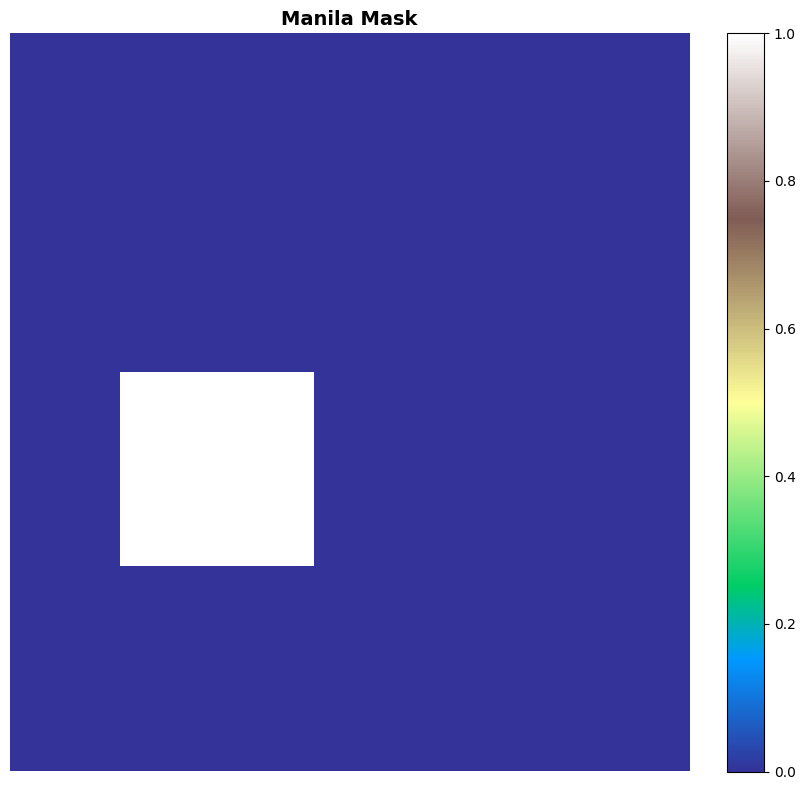

In [5]:
print("\n--- Loading Manila Mask ---")
mask_path = os.path.join(manila_path, "manila_box_3857.tif")
if os.path.exists(mask_path):
    mask_data, mask_meta = load_manila_mask(mask_path)
    mask_stats = get_raster_stats(mask_data, "Mask")
    print_raster_stats(mask_stats)
else:
    print(f"WARNING: Mask file not found at {mask_path}")

fig1 = visualize_raster(mask_data, title="Manila Mask", cmap='terrain')

In [6]:
print("\n" + "="*70)
print("PHASE 1.3: MANILA BOX MASK PROCESSING")
print("="*70)

from scipy.ndimage import zoom

# Current mask shape vs required shape
print(f"\nCurrent mask shape: {mask_data.shape}")
# Resize mask to match raster dimensions
target_shape = (1224, 1125)
zoom_factors = (target_shape[0] / mask_data.shape[0], 
                target_shape[1] / mask_data.shape[1])
print(f"\nZoom factors: {zoom_factors}")
mask_resized = zoom(mask_data, zoom_factors, order=0)  # order=0 = nearest neighbor
print(f"Resized mask shape: {mask_resized.shape}")

# Verify values remain binary
unique_values = np.unique(mask_resized)
print(f"Unique values in resized mask: {unique_values}")

# Statistics
mask_resized_stats = get_raster_stats(mask_resized, "Manila Mask (Resized)")
print_raster_stats(mask_resized_stats)
manila_box_mask = mask_resized


PHASE 1.3: MANILA BOX MASK PROCESSING

Current mask shape: (389, 358)

Zoom factors: (3.146529562982005, 3.142458100558659)
Resized mask shape: (1224, 1125)
Unique values in resized mask: [0. 1.]

Statistics for: Manila Mask (Resized)
Shape:         (1224, 1125)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0751
Std dev:       0.2635
Valid pixels:  1,377,000 / 1,377,000



In [7]:
print("\n  Variables ready for Phase 2:")
print(f"  - train_dem_data (train): {train_dem_data.shape}")
print(f"  - train_infilt_data (train): {train_infilt_data.shape}")
print(f"  - train_landuse_data (train): {train_landuse_data.shape}")
print(f"  - dem_data_test (test): {dem_data_test.shape}")
print(f"  - infilt_data_test (test): {infilt_data_test.shape}")
print(f"  - landuse_data_test (test): {landuse_data_test.shape}")
print(f"  - flood_maps_train (train): {len(flood_maps_train)} maps")
print(f"  - flood_maps_test (test): {len(flood_maps_test)} maps")



  Variables ready for Phase 2:
  - train_dem_data (train): (1224, 1125)
  - train_infilt_data (train): (1224, 1125)
  - train_landuse_data (train): (1224, 1125)
  - dem_data_test (test): (1224, 1125)
  - infilt_data_test (test): (1224, 1125)
  - landuse_data_test (test): (1224, 1125)
  - flood_maps_train (train): 50 maps
  - flood_maps_test (test): 50 maps


# Data Preprocessing

In [8]:
from data_preprocessing import preprocess_spatial_data
import matplotlib.pyplot as plt

preprocessed = preprocess_spatial_data(
    train_dem=train_dem_data,
    train_infilt=train_infilt_data,
    train_landuse=train_landuse_data,
    test_dem=dem_data_test,
    test_infilt=infilt_data_test,
    test_landuse=landuse_data_test,
    mask=manila_box_mask,
    target_shape=(1152, 1152),      
    nodata_method='interpolate', 
    norm_method='minmax'  
)


PHASE 2: SPATIAL INPUT PREPROCESSING

[2.1] Handling NoData Values
----------------------------------------------------------------------
  DEM (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  DEM (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor
  Infiltration (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  Infiltration (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor
  Landuse (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  Landuse (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor

✓ NoData handling complete

[2.2] Resizing to (1152, 1152)
----------------------------------------------------------------------
  Current: (1224, 1125)
  Target: (1152, 1152)
  Train DEM: (1224, 1125) → (1152, 1152) (bilinear)
  Train Infiltration: (1224, 1125) → (1152, 1152) (bilinear)
  Train Landuse: (1224, 1125) → (1152, 1152) (nearest)
  T

In [9]:
# Extract preprocessed data
train_dem_preprocessed = preprocessed['train']['dem']
train_infilt_preprocessed = preprocessed['train']['infiltration']
train_landuse_preprocessed = preprocessed['train']['landuse']
test_dem_preprocessed = preprocessed['test']['dem']
test_infilt_preprocessed = preprocessed['test']['infiltration']
test_landuse_preprocessed = preprocessed['test']['landuse']
mask_preprocessed = preprocessed['mask']

print(f"  - train_dem_preprocessed: {train_dem_preprocessed.shape}")
print(f"  - train_infilt_preprocessed: {train_infilt_preprocessed.shape}")
print(f"  - train_landuse_preprocessed: {train_landuse_preprocessed.shape}")
print(f"  - test_dem_preprocessed: {test_dem_preprocessed.shape}")
print(f"  - test_infilt_preprocessed: {test_infilt_preprocessed.shape}")
print(f"  - test_landuse_preprocessed: {test_landuse_preprocessed.shape}")
print(f"  - mask_preprocessed: {mask_preprocessed.shape}")
print(f"  - flood_maps_train: {len(flood_maps_train)} scenarios")
print(f"  - flood_maps_test: {len(flood_maps_test)} scenarios")


  - train_dem_preprocessed: (1152, 1152)
  - train_infilt_preprocessed: (1152, 1152)
  - train_landuse_preprocessed: (1152, 1152)
  - test_dem_preprocessed: (1152, 1152)
  - test_infilt_preprocessed: (1152, 1152)
  - test_landuse_preprocessed: (1152, 1152)
  - mask_preprocessed: (1152, 1152)
  - flood_maps_train: 50 scenarios
  - flood_maps_test: 50 scenarios


# Rainfall 

In [10]:
print("LOADING RAINFALL SCENARIOS")
# Load rainfall scenarios
rainfall_scenarios = load_all_rainfall_scenarios(rs_path)

if len(rainfall_scenarios) > 0:
    print(f"\nRainfall scenarios successfully loaded: {len(rainfall_scenarios)}")
else:
    print("WARNING: No rainfall scenarios loaded!")

LOADING RAINFALL SCENARIOS

Rainfall scenarios successfully loaded: 50


In [11]:
from rainfall import preprocess_rainfall_sequences, visualize_rainfall_sequences, visualize_conditioning_vectors

# Preprocess rainfall sequences
rainfall_results = preprocess_rainfall_sequences(rainfall_scenarios=rainfall_scenarios, norm_method='global_max', info_csv_path='./info.csv')

# Output now includes:
rainfall_results['conditioning_vectors']  
rainfall_results['encoding_info']      


PHASE 3: RAINFALL TEMPORAL SEQUENCE PREPROCESSING

[3.1] Extracting Rainfall Sequences
----------------------------------------------------------------------
  RS01: 13 timesteps, peak=92.49 mm/hr at t=2
  RS02: 13 timesteps, peak=14.60 mm/hr at t=2
  RS03: 13 timesteps, peak=82.76 mm/hr at t=2
  RS04: 13 timesteps, peak=131.44 mm/hr at t=2
  RS05: 13 timesteps, peak=41.38 mm/hr at t=2
  RS06: 13 timesteps, peak=80.32 mm/hr at t=2
  RS07: 13 timesteps, peak=26.77 mm/hr at t=2
  RS08: 13 timesteps, peak=51.11 mm/hr at t=2
  RS09: 13 timesteps, peak=189.85 mm/hr at t=2
  RS10: 13 timesteps, peak=99.79 mm/hr at t=2
  RS11: 13 timesteps, peak=58.74 mm/hr at t=5
  RS20: 13 timesteps, peak=78.89 mm/hr at t=5
  RS21: 13 timesteps, peak=34.08 mm/hr at t=9
  RS30: 13 timesteps, peak=51.11 mm/hr at t=9
  RS31: 13 timesteps, peak=14.77 mm/hr at t=4
  RS50: 13 timesteps, peak=27.69 mm/hr at t=1

✓ Extracted 50 sequences
  Shape: (50, 13)
  ✓ All sequences have 13 timesteps

[3.2] Normalizing Sequ

{'pattern_encoding': {0: 'SCS‑style front-loaded (convective – similar to NRCS Type II)',
  1: 'SCS-style balanced (intermediate)',
  2: 'SCS-style back-loaded (frontal – similar to Type I)',
  3: 'Triangular / Chicago-style with peak at fraction of duration'},
 'max_depth_mm': 78.0,
 'conditioning_dims': 4,
 'dim_names': ['pattern_type', 'depth_normalized', 'tpeak', 'has_tpeak'],
 'pattern_names': ['Front-loaded', 'Balanced', 'Back-loaded', 'Triangular']}

# Ground Truth (Flood Maps)

In [12]:
from flood_maps import categorize_flood_maps, resize_flood_maps, visualize_categorized_maps  

# Create masks (train = GMM outskirts, test = Manila core)
train_mask = 1 - mask_preprocessed  # Inverse of Manila box
test_mask = mask_preprocessed       # Manila box

flood_maps_train_resized = resize_flood_maps(flood_maps=flood_maps_train, target_shape=(1152, 1152), split_name='Train')
flood_maps_test_resized = resize_flood_maps(flood_maps=flood_maps_test, target_shape=(1152, 1152), split_name='Test')


Resizing Train Flood Maps
----------------------------------------------------------------------
  Current shape: (1224, 1125)
  Target shape: (1152, 1152)
  Zoom factors: (0.9411764705882353, 1.024)
  Resizing 50 flood maps...
    Progress: 5/50 maps resized
    Progress: 10/50 maps resized
    Progress: 15/50 maps resized
    Progress: 20/50 maps resized
    Progress: 25/50 maps resized
    Progress: 30/50 maps resized
    Progress: 35/50 maps resized
    Progress: 40/50 maps resized
    Progress: 45/50 maps resized
    Progress: 50/50 maps resized
  ✓ All flood maps resized to (1152, 1152)

Resizing Test Flood Maps
----------------------------------------------------------------------
  Current shape: (1224, 1125)
  Target shape: (1152, 1152)
  Zoom factors: (0.9411764705882353, 1.024)
  Resizing 50 flood maps...
    Progress: 5/50 maps resized
    Progress: 10/50 maps resized
    Progress: 15/50 maps resized
    Progress: 20/50 maps resized
    Progress: 25/50 maps resized
    Pro

In [13]:
# Categorize flood maps
categorization_results = categorize_flood_maps(
    train_flood_maps=flood_maps_train_resized,      
    test_flood_maps=flood_maps_test_resized,        
    train_mask=train_mask,
    test_mask=test_mask,
    patch_size=PATCH_SIZE,                          
    categorization_method='majority_vote',   
    class_thresholds=[0.32, 0.48, 0.97, 1.46]
)


PHASE 4: FLOOD MAP CATEGORIZATION

[4.1] Flood Susceptibility Classes
----------------------------------------------------------------------
  Class 0 - No Flood    : [0.00, 0.32) meters
  Class 1 - Light       : [0.32, 0.48) meters
  Class 2 - Moderate    : [0.48, 0.97) meters
  Class 3 - Heavy       : [0.97, 1.46) meters
  Class 4 - Extreme     : [1.46, ∞) meters

[4.2] Patch Configuration
----------------------------------------------------------------------
  Spatial shape: (1152, 1152)
  Patch size: 4×4
  Patches per dimension: 288×288
  Total patches: 82,944
  Categorization method: majority_vote

[4.3] Categorizing Flood Maps
----------------------------------------------------------------------

  Train Set (50 scenarios):
    RS01: 76,553 valid patches, 6,391 NoData
    RS02: 76,553 valid patches, 6,391 NoData
    RS03: 76,553 valid patches, 6,391 NoData
    RS04: 76,553 valid patches, 6,391 NoData
    RS05: 76,553 valid patches, 6,391 NoData
    RS06: 76,553 valid patches, 6

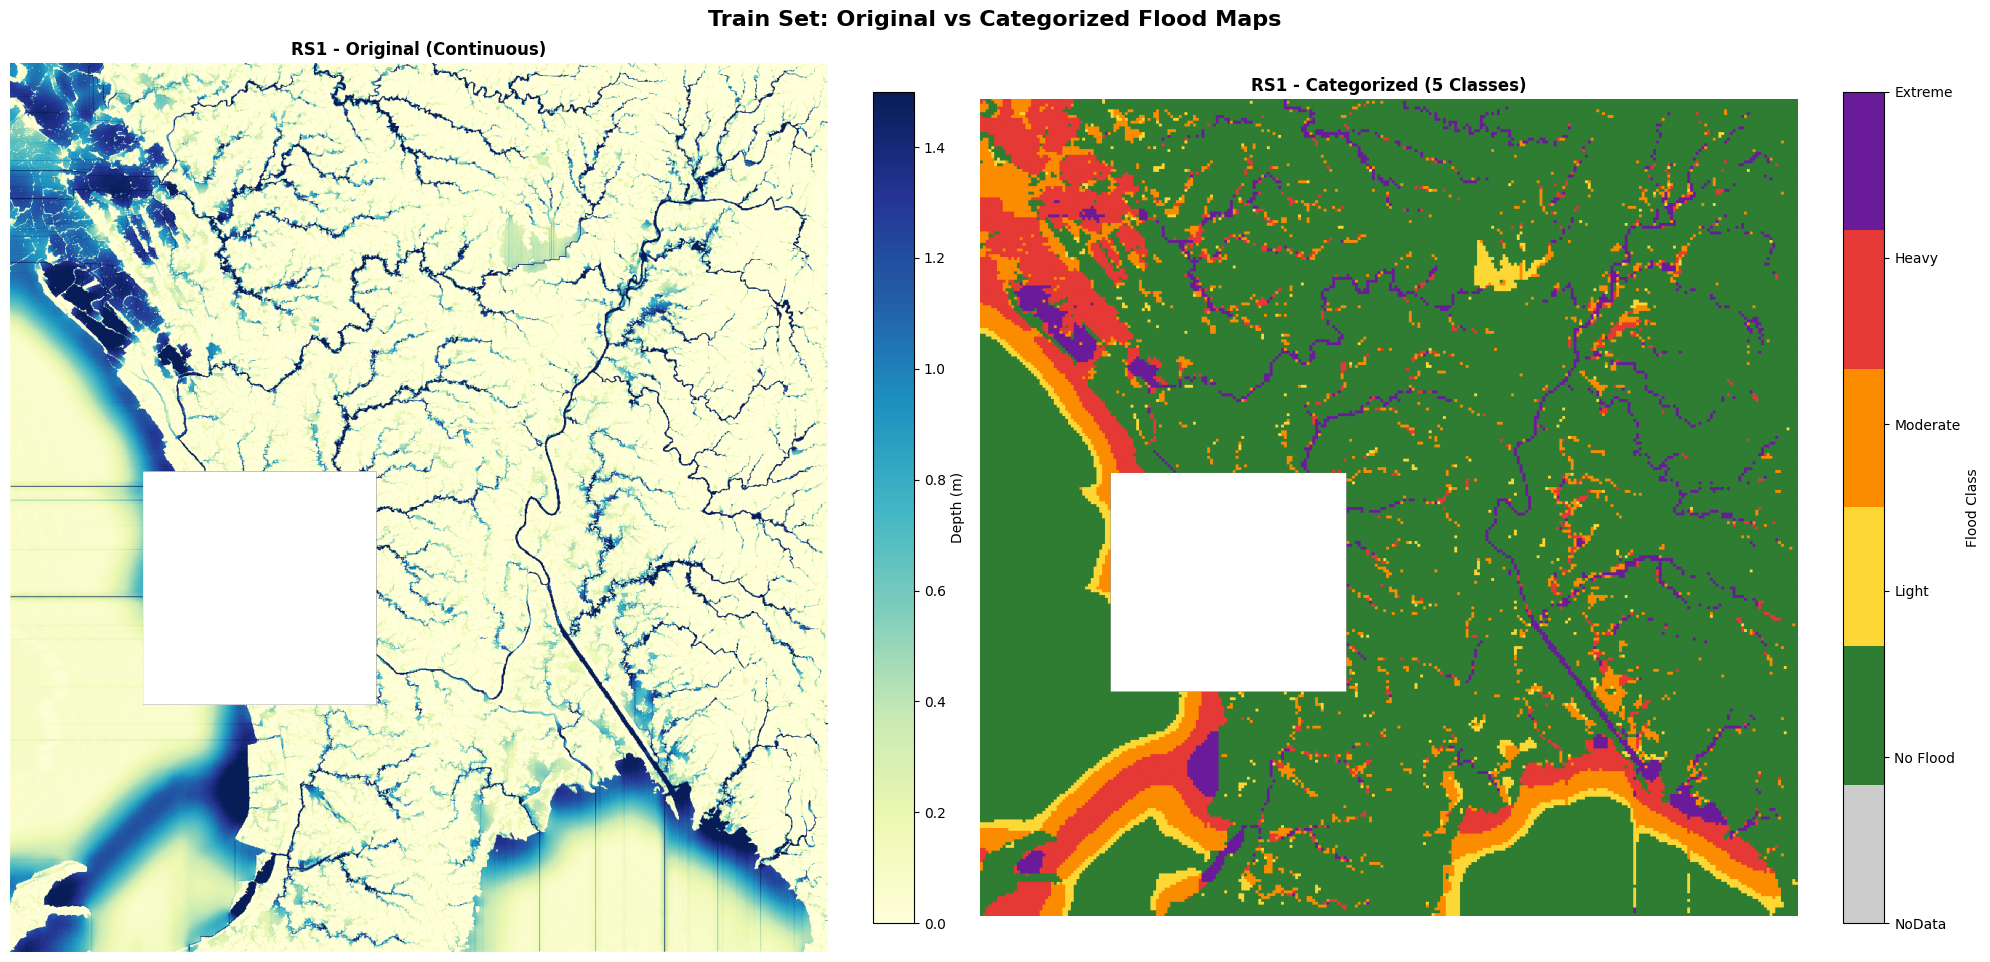

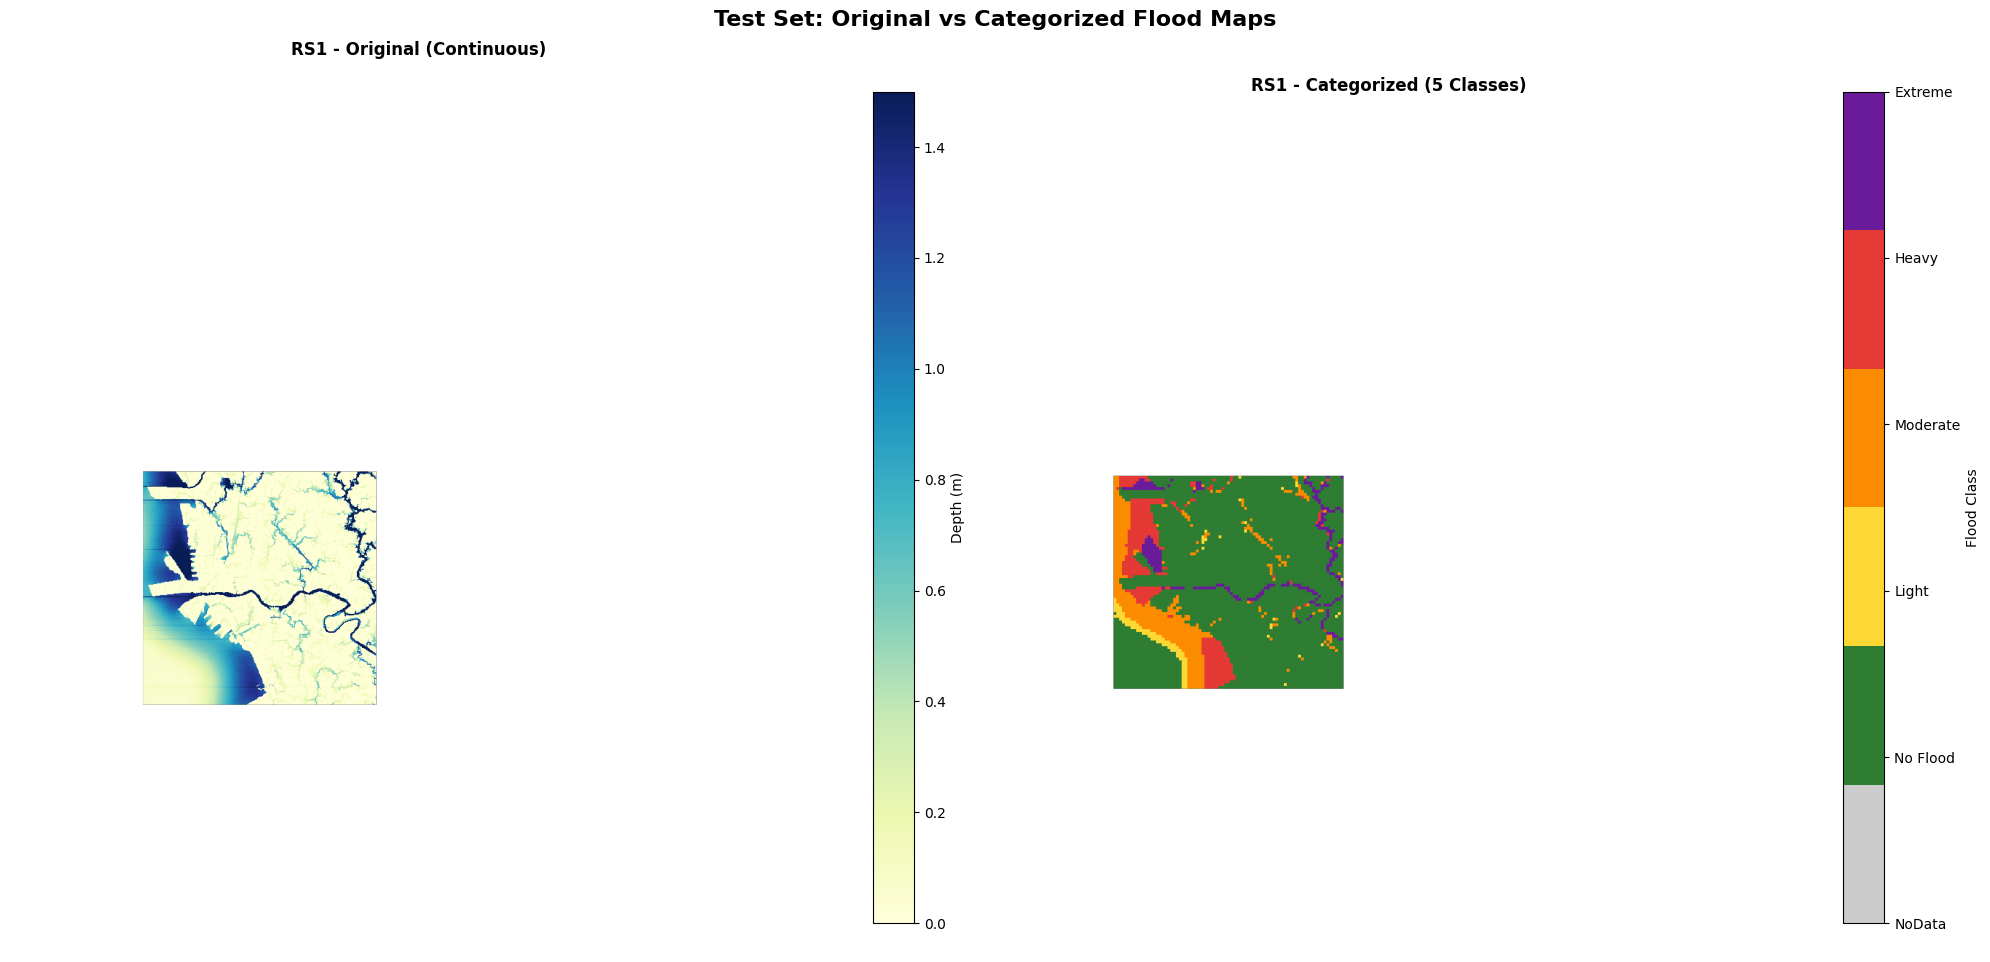

In [14]:
fig1 = visualize_categorized_maps(categorization_results, original_flood_maps=flood_maps_train, split='train', num_scenarios=1)
fig2 = visualize_categorized_maps(categorization_results, original_flood_maps=flood_maps_test, split='test', num_scenarios=1)

# Rainfall-based Partitioning

In [15]:
from data_splitting import split_spatial_data

split_results = split_spatial_data( 
    categorization_results=categorization_results,
    preprocessed_spatial=preprocessed, rainfall_results=rainfall_results,
    train_ratio=0.70, random_seed=42, patch_size=PATCH_SIZE
)

X_train_spatial = split_results['train']['spatial_patches']      
X_train_rainfall = split_results['train']['rainfall_sequences']  
y_train = split_results['train']['labels']                      

X_test_spatial = split_results['test']['spatial_patches']        
X_test_rainfall = split_results['test']['rainfall_sequences']     
y_test = split_results['test']['labels']                         

print(f"\nFinal Dataset Shapes:")
print(f"  Train: {X_train_spatial.shape[0]:,} samples")
print(f"  Test: {X_test_spatial.shape[0]:,} samples")


SPATIAL DATA SPLITTING (WITH CONDITIONING)

[5.1] Spatial Split Logic
----------------------------------------------------------------------
  Data Structure:
    • Train region: Greater Metro Manila (GMM) - outside Manila box
    • Test region: Metro Manila core - inside Manila box
    • Spatially complementary (non-overlapping)

  Split Strategy:
    • All 50 scenarios used for BOTH regions
    • Training scenarios → GMM patches
    • Testing scenarios → Manila patches
    • Conditioning vectors replicated per patch (NEW)

[5.2] Spatial Masks
----------------------------------------------------------------------
  Total pixels: 1,327,104
  GMM region (train): 1,227,417 pixels (92.5%)
  Manila region (test): 99,687 pixels (7.5%)
  Coverage check: 1,327,104 / 1,327,104 ✓

  Patch Alignment:
    Train (GMM): 76,553 patches
    Test (Manila): 6,075 patches

[5.3] Random Scenario Assignment
----------------------------------------------------------------------
  Total scenarios: 50
  Tra

In [16]:
import numpy as np
from pathlib import Path
from config import TrainConfig

cfg = TrainConfig()
cfg.output_ped_dir.mkdir(parents=True, exist_ok=True)

PATCH_SIZE         = 4
N_TEST_SCENARIOS   = 15
N_PATCHES_EXPECTED = 6075  

manila_mask = split_results['masks']['manila_mask'] 
H, W = manila_mask.shape

patch_rows, patch_cols = [], []
for r in range(0, H - PATCH_SIZE + 1, PATCH_SIZE):
    for c in range(0, W - PATCH_SIZE + 1, PATCH_SIZE):
        if manila_mask[r:r + PATCH_SIZE, c:c + PATCH_SIZE].mean() == 1.0:
            patch_rows.append(r)
            patch_cols.append(c)

patch_indices = np.stack([patch_rows, patch_cols], axis=1).astype(np.int32)

print(f"  manila_mask pixels    : {manila_mask.sum()}")          # 99687
print(f"  patch_indices derived : {patch_indices.shape[0]}")     # must be 6075
print(f"  X_test_spatial        : {X_test_spatial.shape}")       # (91125, 3, 4, 4)

assert patch_indices.shape[0] == N_PATCHES_EXPECTED, (
    f"Expected {N_PATCHES_EXPECTED}, got {patch_indices.shape[0]}. "
    f"Check PATCH_SIZE or manila_mask."
)

unique_spatial = X_test_spatial[:N_PATCHES_EXPECTED]   # (6075, 3, 4, 4)

assert unique_spatial.shape == (N_PATCHES_EXPECTED, 3, PATCH_SIZE, PATCH_SIZE), \
    f"Unexpected unique_spatial shape: {unique_spatial.shape}"

# ── Save ───────────────────────────────────────────────────────────────────────
save_path = cfg.output_ped_dir / 'spatial_data.npz'
np.savez(
    save_path,
    spatial       = unique_spatial,        # (6075, 3, 4, 4)
    patch_indices = patch_indices,         # (6075, 2)
    dem           = test_dem_preprocessed, # (1152, 1152)
)

print(f"\n  ✓ Saved → {save_path}")
print(f"    spatial       : {unique_spatial.shape}")
print(f"    patch_indices : {patch_indices.shape}")
print(f"    dem           : {test_dem_preprocessed.shape}")

  manila_mask pixels    : 99687
  patch_indices derived : 6075
  X_test_spatial        : (91125, 3, 4, 4)

  ✓ Saved → outputs_ped\spatial_data.npz
    spatial       : (6075, 3, 4, 4)
    patch_indices : (6075, 2)
    dem           : (1152, 1152)


# Patchify

In [17]:
from patchify import extract_vit_patches, get_data_loader_ready
vit_results = extract_vit_patches(split_results=split_results,patch_size=PATCH_SIZE)

train_data, test_data = get_data_loader_ready(vit_results)
X_train_spatial, X_train_rainfall, X_train_conditioning, y_train = train_data
X_test_spatial, X_test_rainfall, X_test_conditioning, y_test = test_data

print(f"   Train: {len(y_train):,} samples")
print(f"   Test: {len(y_test):,} samples")


PHASE 6: PATCH EXTRACTION FOR ViT

[6.1] Patch Configuration
----------------------------------------------------------------------
  Spatial shape: (1152, 1152)
  Patch size: 4×4
  Patches per dimension: 288×288
  Total possible patches: 82,944
  Stride: 4 (non-overlapping)

[6.2] Data Already Extracted in Phase 5
----------------------------------------------------------------------
  ✓ Spatial patches extracted and masked
  ✓ Rainfall sequences prepared
  ✓ Labels categorized

[6.3] Format Verification
----------------------------------------------------------------------
  Training Set:
    Spatial patches: (2679355, 3, 4, 4) (N, C, H, W)
    Rainfall seqs:   (2679355, 13) (N, T)
    Labels:          (2679355,) (N,)

  Test Set:
    Spatial patches: (91125, 3, 4, 4) (N, C, H, W)
    Rainfall seqs:   (91125, 13) (N, T)
    Labels:          (91125,) (N,)

[6.4] Quality Checks
----------------------------------------------------------------------
  spatial_shape_correct: ✓
  rainfall

# Dataset

In [18]:
from dataset import create_complete_dataset

dataset = create_complete_dataset(vit_results=vit_results)

X_train_spatial = dataset['train']['spatial']
X_train_rainfall = dataset['train']['rainfall']
X_train_conditioning = dataset['train']['conditioning'] 
y_train = dataset['train']['labels']
train_metadata   = dataset['train']['metadata']

X_test_spatial = dataset['test']['spatial']
X_test_rainfall = dataset['test']['rainfall']
X_test_conditioning = dataset['test']['conditioning']   
y_test = dataset['test']['labels']
test_metadata    = dataset['test']['metadata']

print(f"  X_train_spatial: {X_train_spatial.shape}")
print(f"  X_test_spatial: {X_test_spatial.shape}")
print(f"  X_train_conditioning: {X_train_conditioning.shape}")

print(f"  y_train: {len(y_train):,} samples")
print(f"  y_test: {len(y_test):,} samples")
print(f"  X_test_conditioning: {X_test_conditioning.shape}")



PHASE 7: CREATE COMPLETE DATASET (WITH CONDITIONING)

[7.1-7.2] Dataset Structure
----------------------------------------------------------------------
  Training Dataset:
    Spatial patches:    (2679355, 3, 4, 4)
    Rainfall sequences: (2679355, 13)
    Conditioning vecs:  (2679355, 4)
    Labels:             (2679355,)
    Total samples:      2,679,355

  Test Dataset:
    Spatial patches:    (91125, 3, 4, 4)
    Rainfall sequences: (91125, 13)
    Conditioning vecs:  (91125, 4)
    Labels:             (91125,)
    Total samples:      91,125

[7.3] Data Validation
----------------------------------------------------------------------
  Shape consistency: ✓
  No NaN values: ✓
  Label range [0-4]: ✓
  Data normalized [0-1]: ✓
  Conditioning dims (4): ✓
  Pattern types [0-3]: ✓

  Class Distribution:
    Class      Train                Test                
    --------------------------------------------------
    0 (No Flood): 2,125,579 ( 79.3%)  73,183 ( 80.3%)
    1 (Light   ): 6

# Training

In [19]:
from pathlib import Path
from config import TrainConfig
from training import FloodPatchDataset, train_kfold, plot_fold_histories
import matplotlib.pyplot as plt

cfg = TrainConfig() 
cfg.use_conditioning = True

cfg.output_ped_dir.mkdir(parents=True, exist_ok=True)
(cfg.output_ped_dir / 'logs').mkdir(parents=True, exist_ok=True)
cfg.save(cfg.output_ped_dir / 'logs' / 'config.json')

full_dataset = FloodPatchDataset(X_train_spatial, y_train, X_train_rainfall, X_train_conditioning)

fold_histories, best_fold_idx = train_kfold(
    full_dataset, 
    y_train, 
    cfg,
    ckpt_dir=cfg.output_ped_dir / 'checkpoints',
    log_dir=cfg.output_ped_dir / 'logs'
)

fig = plot_fold_histories(fold_histories, save_path=cfg.output_ped_dir / 'logs' / 'fold_curves.png')
plt.close(fig)

[FloodPatchDataset]  2,679,355 samples ✓ with conditioning (2679355, 4)
  Spatial : (2679355, 3, 4, 4)
  Rainfall: (2679355, 13)
  Conditioning: (2679355, 4)
  Labels  : (2679355,)

Class weights (power=0.5):
  Class 0 (No Flood  ): 79.33%  →  weight 0.5021
  Class 1 (Light     ):  2.28%  →  weight 2.9600
  Class 2 (Moderate  ):  5.72%  →  weight 1.8703
  Class 3 (Heavy     ):  3.71%  →  weight 2.3205
  Class 4 (Extreme   ):  8.95%  →  weight 1.4945
  Loss: CombinedLoss (ce=0.9, dice=0.1)

FOLD 1 / 2
  Train: 1,339,677  |  Val: 1,339,678
    [TRAIN]   500/1309  loss=0.9225  acc=0.8041
    [TRAIN]  1000/1309  loss=0.8900  acc=0.8078
    [TRAIN]  1309/1309  loss=0.8811  acc=0.8081
    [VAL  ]   500/1309  loss=0.8435  acc=0.8207
    [VAL  ]  1000/1309  loss=0.8429  acc=0.8204
    [VAL  ]  1309/1309  loss=0.8433  acc=0.8203
  Epoch  1/20 (93s)  lr=0.00e+00  train loss=0.8811  acc=0.8081  val loss=0.8433  acc=0.8203  f1=0.4616  prec=0.5243  rec=0.4735  iou=0.3692
    [TRAIN]   500/1309  los

# Test

In [20]:
from training import FloodPatchDataset, make_model, evaluate
from torch.utils.data import DataLoader
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load best fold checkpoint ──────────────────────────────────────
best_model = make_model(cfg).to(DEVICE)
ckpt = torch.load(cfg.output_ped_dir / 'checkpoints' / f'fold_{best_fold_idx+1}_best.pth',map_location=DEVICE, weights_only=False)
best_model.load_state_dict(ckpt['model_state_dict'])
print(f"\nLoaded fold {best_fold_idx+1} best model  "f"({cfg.checkpoint_metric}={ckpt['best_monitor']:.4f})")

# ── Final test evaluation ──────────────────────────────────────────
test_dataset = FloodPatchDataset(X_test_spatial, y_test, X_test_rainfall, X_test_conditioning)
test_loader  = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False,num_workers=2, pin_memory=DEVICE.type == 'cuda')

evaluate(best_model, test_loader, cfg, log_dir=cfg.output_ped_dir / 'logs', split_name='Test')


Loaded fold 1 best model  (macro_f1=0.5189)
[FloodPatchDataset]  91,125 samples ✓ with conditioning (91125, 4)
  Spatial : (91125, 3, 4, 4)
  Rainfall: (91125, 13)
  Conditioning: (91125, 4)
  Labels  : (91125,)

Test Metrics
  Accuracy         : 0.8262
  Macro F1         : 0.5295
  Weighted F1      : 0.8430
  Macro Precision  : 0.5350
  Macro Recall     : 0.5556
  Macro IoU        : 0.4184
  Critical Recall (Heavy+Extreme): 0.5950

  Class            Prec      Rec       F1      IoU
  ------------------------------------------------
  No Flood       0.9582   0.8976   0.9269   0.8638
  Light          0.2642   0.4093   0.3211   0.1913
  Moderate       0.2899   0.5700   0.3843   0.2379
  Heavy          0.2391   0.1722   0.2002   0.1112
  Extreme        0.9238   0.7290   0.8150   0.6877
  Results → outputs_ped\logs/test_results.json


{'accuracy': 0.8262057613168724,
 'macro_f1': 0.5294981635017902,
 'weighted_f1': 0.8430151006992622,
 'macro_precision': 0.5350304097259232,
 'macro_recall': 0.5556291772159804,
 'macro_iou': 0.4183678201717739,
 'iou_per_class': [0.8637606837606837,
  0.1912560096153846,
  0.23787438094489427,
  0.11123275673308518,
  0.687715269804822],
 'precision_No Flood': 0.9581801738724547,
 'recall_No Flood': 0.8975991692059632,
 'f1_No Flood': 0.926900852976245,
 'iou_No Flood': 0.8637606837606837,
 'precision_Light': 0.2641626893546379,
 'recall_Light': 0.40932475884244374,
 'f1_Light': 0.32109976037331317,
 'iou_Light': 0.1912560096153846,
 'precision_Moderate': 0.2899022801302932,
 'recall_Moderate': 0.5699755132793369,
 'f1_Moderate': 0.38432717342985967,
 'iou_Moderate': 0.23787438094489427,
 'precision_Heavy': 0.23905882352941177,
 'recall_Heavy': 0.17220338983050848,
 'f1_Heavy': 0.20019704433497537,
 'iou_Heavy': 0.11123275673308518,
 'precision_Extreme': 0.9238480817428186,
 'recall_

# Prediction

In [21]:
from prediction import (build_eval_results, reconstruct_ground_truth_maps, generate_prediction_maps, plot_flood_on_dem, plot_best_worst_dem)

gt_maps      = reconstruct_ground_truth_maps(test_metadata, y_test)
results      = generate_prediction_maps(best_model, test_loader, test_metadata, cfg, output_dir=cfg.output_ped_dir / 'predictions')
eval_results = build_eval_results(gt_maps, results['predictions'], cfg)

dem_for_plot = test_dem_preprocessed.astype(np.float32)

best_idx  = eval_results['aggregate']['best_idx']
worst_idx = eval_results['aggregate']['worst_idx']

(cfg.output_ped_dir / 'predictions').mkdir(parents=True, exist_ok=True)


[Reconstructing Ground Truth Maps]
  Scenario 3: 6075 patches
  Scenario 8: 6075 patches
  Scenario 11: 6075 patches
  Scenario 15: 6075 patches
  Scenario 19: 6075 patches
  Scenario 21: 6075 patches
  Scenario 23: 6075 patches
  Scenario 24: 6075 patches
  Scenario 29: 6075 patches
  Scenario 36: 6075 patches
  Scenario 39: 6075 patches
  Scenario 41: 6075 patches
  Scenario 43: 6075 patches
  Scenario 44: 6075 patches
  Scenario 50: 6075 patches
✓ Reconstructed 15 ground truth maps

PREDICTION PIPELINE


  Predicting: 100%|██████████| 89/89 [00:06<00:00, 14.46it/s]


  Scenario 3: 6075 patches
  Scenario 8: 6075 patches
  Scenario 11: 6075 patches
  Scenario 15: 6075 patches
  Scenario 19: 6075 patches
  Scenario 21: 6075 patches
  Scenario 23: 6075 patches
  Scenario 24: 6075 patches
  Scenario 29: 6075 patches
  Scenario 36: 6075 patches
  Scenario 39: 6075 patches
  Scenario 41: 6075 patches
  Scenario 43: 6075 patches
  Scenario 44: 6075 patches
  Scenario 50: 6075 patches

  Confidence — mean=0.7662  median=0.8679  std=0.2299  range=[0.2277, 0.9996]
  Low(<0.5)=20.8%  Mid=20.5%  High(>0.8)=58.6%

✓ Done — results in: outputs_ped\predictions

✓ Eval: 15 scenarios  |  Best RS23 F1=0.439  |  Worst RS39 F1=0.224


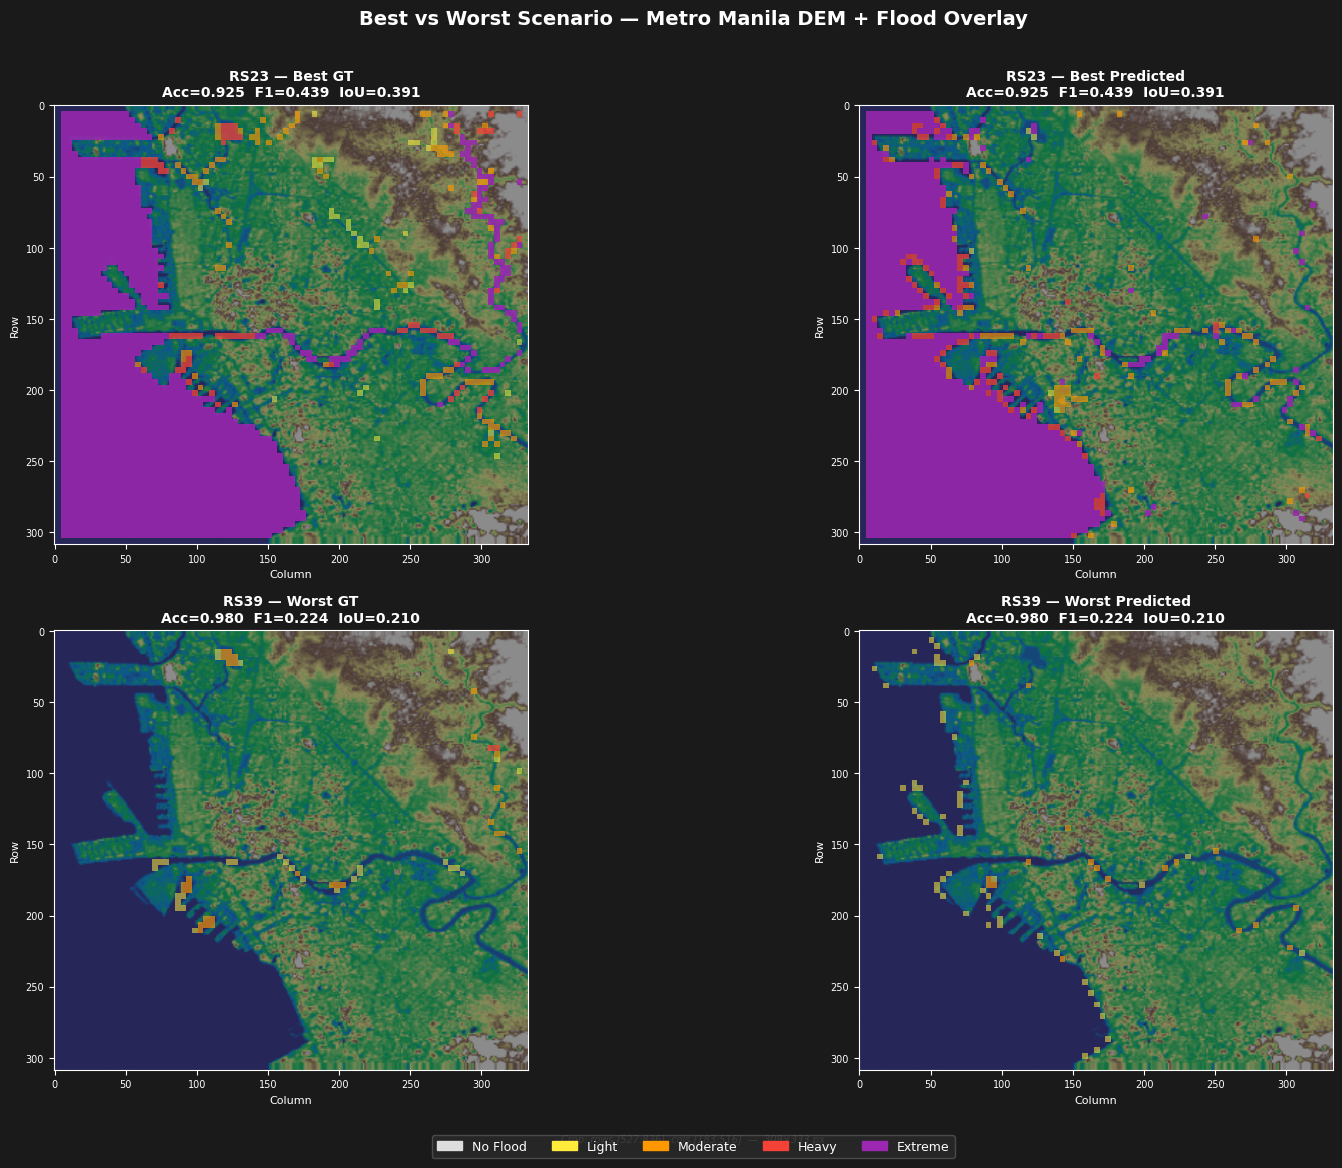

In [22]:
fig_grid = plot_best_worst_dem(dem=dem_for_plot, results=eval_results, figsize=(18, 11))
fig_grid.savefig(cfg.output_ped_dir / 'predictions' / 'eval_dem_best_worst_grid.png', dpi=150, bbox_inches='tight')

plt.show()

C:\Users\CENSER\AppData\Local\Temp\ipykernel_40264\3669582110.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


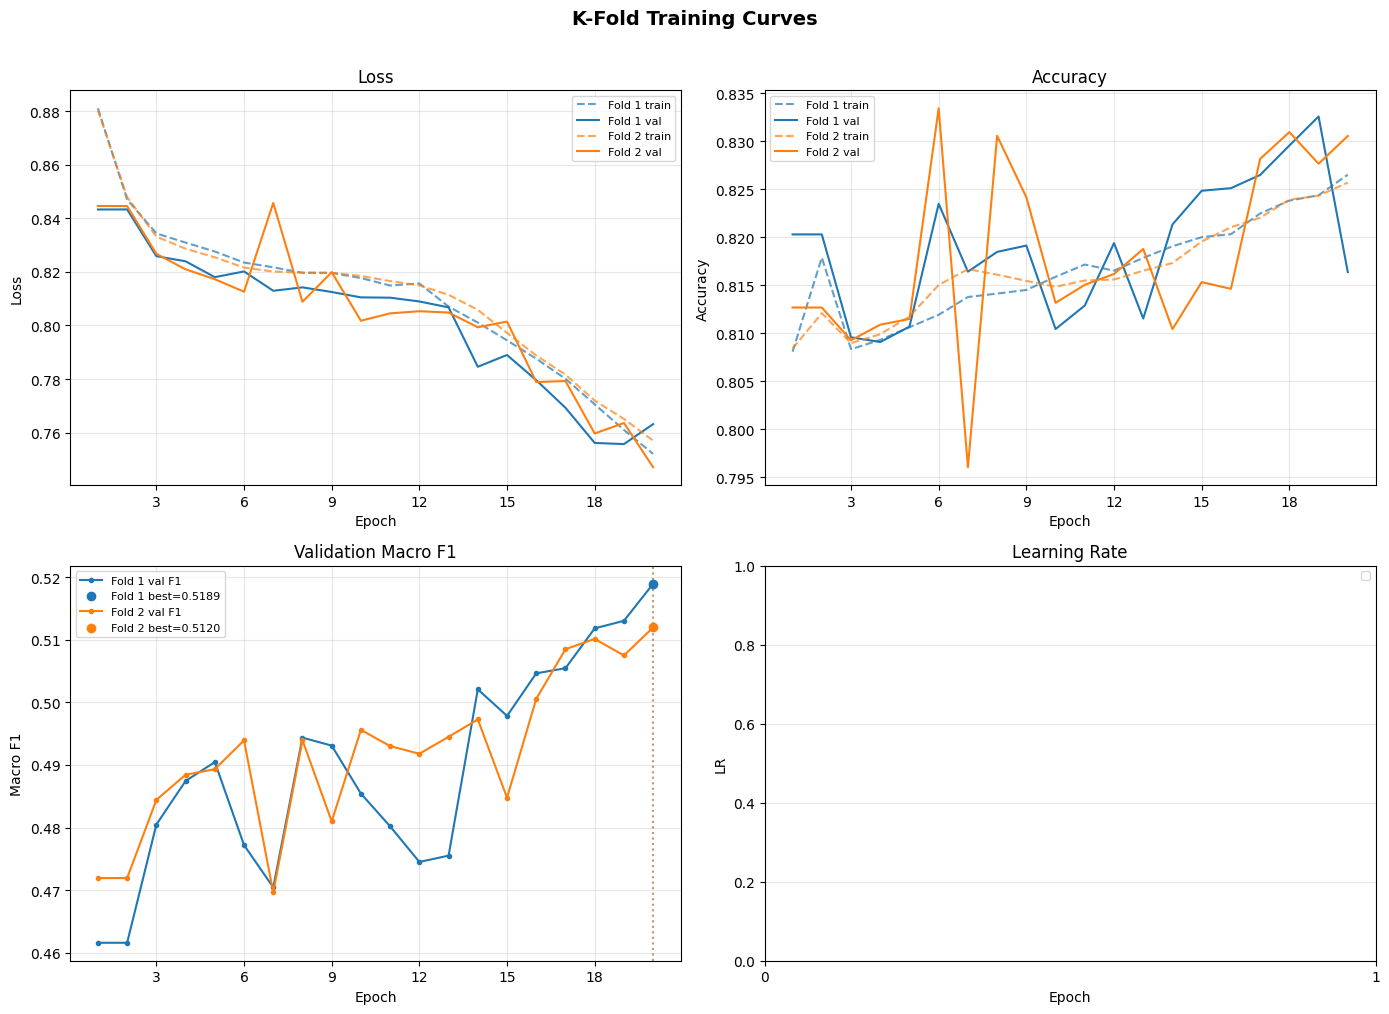

In [23]:
import json

with open(cfg.output_ped_dir / 'logs' / 'fold_histories.json') as f:
    fold_histories_loaded = json.load(f)

def plot_fold_histories(fold_histories, save_path=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, h in enumerate(fold_histories):
        epochs = range(1, len(h['train_loss']) + 1)
        c = colors[i % len(colors)]

        # Loss
        axes[0].plot(epochs, h['train_loss'], label=f'Fold {i+1} train',
                     linestyle='--', color=c, alpha=0.7)
        axes[0].plot(epochs, h['val_loss'],   label=f'Fold {i+1} val',
                     linestyle='-',  color=c)

        # Accuracy
        axes[1].plot(epochs, h['train_acc'], label=f'Fold {i+1} train',
                     linestyle='--', color=c, alpha=0.7)
        axes[1].plot(epochs, h['val_acc'],   label=f'Fold {i+1} val',
             linestyle='-',  color=c) 

        # Macro F1
        axes[2].plot(epochs, h['val_f1'], label=f'Fold {i+1} val F1',
                     linestyle='-', color=c, marker='o', markersize=3)
        best_epoch = h['val_f1'].index(max(h['val_f1'])) + 1
        axes[2].axvline(best_epoch, color=c, linestyle=':', alpha=0.5)
        axes[2].scatter([best_epoch], [max(h['val_f1'])], color=c, zorder=5,
                        label=f'Fold {i+1} best={max(h["val_f1"]):.4f}')

        # LR schedule
        if 'lr' in h:
            axes[3].plot(epochs, h['lr'], label=f'Fold {i+1}',
                         linestyle='-', color=c)

    titles  = ['Loss', 'Accuracy', 'Validation Macro F1', 'Learning Rate']
    ylabels = ['Loss', 'Accuracy', 'Macro F1', 'LR']
    for ax, title, ylabel in zip(axes, titles, ylabels):
        ax.set(xlabel='Epoch', ylabel=ylabel, title=title)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle('K-Fold Training Curves', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    return fig

fig = plot_fold_histories(fold_histories_loaded, save_path=cfg.output_ped_dir / 'logs' / 'fold_curves.png')
plt.show()

# Hyperparameter Tuning

In [24]:
from pathlib import Path
from config import TrainConfig
from training import FloodPatchDataset, train_kfold, plot_fold_histories, make_model
import matplotlib.pyplot as plt
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from copy import deepcopy
from sklearn.model_selection import KFold, train_test_split
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score
import torch.nn.functional as F

# ========== CONFIG & SETUP ==========
cfg = TrainConfig() 
cfg.use_conditioning = True

cfg.output_ped_dir.mkdir(parents=True, exist_ok=True)
(cfg.output_ped_dir / 'logs_tuned').mkdir(parents=True, exist_ok=True)
cfg.save(cfg.output_ped_dir / 'logs_tuned' / 'config.json')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}\n")

# ========== EXTRACT LABELS ==========
print("="*70)
print(" DATA PREPARATION")
print("="*70)

print("\nExtracting labels from full dataset...", end='', flush=True)
y_full = []
for i in range(len(full_dataset)):
    sample = full_dataset[i]
    label = sample[3]  # Labels are typically the 4th element in FloodPatchDataset
    if isinstance(label, torch.Tensor):
        label = label.item() if label.ndim == 0 else label.argmax().item()
    y_full.append(label)
y_full = np.array(y_full)
print(f" ✓ {len(y_full)} labels extracted")
print(f"  Class distribution: {np.bincount(y_full)}")

# ========== CREATE SUBSET FOR TUNING ==========
print("\nCreating stratified subset for hyperparameter tuning...")
subset_size = 0.5  # Use 50% of data for tuning
tune_indices, _ = train_test_split(
    np.arange(len(y_full)), 
    test_size=1-subset_size, 
    stratify=y_full, 
    random_state=42
)
tune_dataset = torch.utils.data.Subset(full_dataset, tune_indices)
y_tune = y_full[tune_indices]  
print(f"  Tuning set size: {len(y_tune)} samples")
print(f"  Class distribution: {np.bincount(y_tune)}\n")

# ========== HYPERPARAMETER TUNING FUNCTIONS ==========
def compute_loss(model_output, targets, cfg):
    if isinstance(model_output, tuple):
        logits = model_output[0]
    else:
        logits = model_output
    targets = targets.long()
    loss = F.cross_entropy(logits, targets, reduction='mean')
    return loss

def objective(trial: optuna.Trial, tune_dataset, y_tune, base_cfg, fold_val_indices, DEVICE):
    cfg = deepcopy(base_cfg)
    
    # Suggest hyperparameters
    cfg.patch_size          = trial.suggest_categorical('patch_size', [2, 4, 8])    
    cfg.embed_dim           = trial.suggest_categorical('embed_dim', [128, 256, 512])
    cfg.num_heads           = trial.suggest_categorical('num_heads', [4, 8, 16]) 
    cfg.num_layers          = trial.suggest_int('num_layers', 2, 6)
    cfg.mlp_ratio           = trial.suggest_float('mlp_ratio', 1.0, 4.0, step=0.5)
    cfg.dropout             = trial.suggest_float('dropout', 0.0, 0.5, step=0.05)
    cfg.weight_decay        = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    cfg.rainfall_hidden     = trial.suggest_categorical('rainfall_hidden', [32, 64, 128])
    cfg.conditioning_hidden = trial.suggest_categorical('conditioning_hidden', [32, 64, 128])
    cfg.lr                  = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    cfg.warmup_epochs       = trial.suggest_int('warmup_epochs', 5, 20)
    cfg.grad_clip_norm      = trial.suggest_float('grad_clip_norm', 0.5, 2.0, step=0.25)
    cfg.focal_gamma         = trial.suggest_float('focal_gamma', 1.0, 5.0, step=0.5)
    cfg.ce_weight           = trial.suggest_float('ce_weight', 0.5, 0.95, step=0.05)
    cfg.dice_weight         = 1.0 - cfg.ce_weight    
   
    try:
        fold_scores = []
        
        for fold_idx, (train_idx, val_idx) in enumerate(fold_val_indices[:cfg.num_folds]):
            print(f"  Fold {fold_idx + 1}/{cfg.num_folds}...", end='', flush=True)
            
            # Use tune_dataset instead of full_dataset
            train_subset = torch.utils.data.Subset(tune_dataset, train_idx)
            val_subset = torch.utils.data.Subset(tune_dataset, val_idx)
            
            train_loader = DataLoader(train_subset, batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=DEVICE.type == 'cuda')
            val_loader = DataLoader(val_subset, batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=DEVICE.type == 'cuda')
            
            model = make_model(cfg).to(DEVICE)
            optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
            
            best_val_f1 = 0.0
            patience = 3
            no_improve = 0
            
            for epoch in range(min(cfg.num_epochs, 5)):
                # ==================== TRAINING ====================
                model.train()
                
                for batch_data in train_loader:
                    X_spatial, X_rainfall, X_cond, y = batch_data
                    
                    X_spatial = X_spatial.to(DEVICE)
                    X_rainfall = X_rainfall.to(DEVICE)
                    X_cond = X_cond.to(DEVICE)
                    y = y.to(DEVICE).long()
                    
                    optimizer.zero_grad()
                    model_output = model(X_spatial, X_rainfall, X_cond)
                    loss = compute_loss(model_output, y, cfg)
                    
                    loss.backward()
                    
                    if cfg.grad_clip_norm > 0:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)
                    optimizer.step()
                
                # ==================== VALIDATION ====================
                model.eval()
                val_preds = []
                val_targets = []
                
                with torch.no_grad():
                    for batch_data in val_loader:
                        X_spatial, X_rainfall, X_cond, y = batch_data
                        
                        X_spatial = X_spatial.to(DEVICE)
                        X_rainfall = X_rainfall.to(DEVICE)
                        X_cond = X_cond.to(DEVICE)
                        
                        model_output = model(X_spatial, X_rainfall, X_cond)
                        logits = model_output[0] if isinstance(model_output, tuple) else model_output
                        preds = torch.argmax(logits, dim=1).cpu().numpy()
                        
                        val_preds.append(preds)
                        val_targets.append(y.numpy())
                
                val_preds = np.concatenate(val_preds)
                val_targets = np.concatenate(val_targets)
                val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)
                
                # Early stopping
                if val_f1 > best_val_f1:
                    best_val_f1 = val_f1
                    no_improve = 0
                else:
                    no_improve += 1
                
                if no_improve >= patience:
                    break
            
            fold_scores.append(best_val_f1)
            print(f" F1={best_val_f1:.4f}")
        
        mean_f1 = np.mean(fold_scores)
        return mean_f1
        
    except Exception as e:
        print(f"\n  ✗ Trial failed: {str(e)}")
        return 0.0

# ========== PREPARE FOLD INDICES ==========
kfold = KFold(n_splits=cfg.num_folds, shuffle=True, random_state=42)
fold_val_indices = list(kfold.split(y_tune))

# ========== HYPERPARAMETER TUNING ==========
print("="*70)
print("HYPERPARAMETER TUNING")
print("="*70)

base_cfg = deepcopy(cfg)
sampler = TPESampler(seed=42)
pruner = MedianPruner(n_startup_trials=2, n_warmup_steps=2)
study = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)

study.optimize(
    lambda trial: objective(trial, tune_dataset, y_tune, base_cfg, fold_val_indices, DEVICE),
    n_trials=10,
    show_progress_bar=True
)

print("\n" + "="*70)
print("BEST TRIAL")
print("="*70)
print(f"Best F1 Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")

# Update cfg with best hyperparameters
for param, value in study.best_params.items():
    if hasattr(cfg, param):
        setattr(cfg, param, value)

print("\n" + "="*70)
print("FINAL TRAINING (on full dataset)")
print("="*70 + "\n")

# ========== FINAL TRAINING ON FULL DATASET ==========
fold_histories, best_fold_idx = train_kfold(
    full_dataset, 
    y_train, 
    cfg,
    ckpt_dir=cfg.output_ped_dir / 'checkpoints_tuned',
    log_dir=cfg.output_ped_dir / 'logs_tuned'
)

fig = plot_fold_histories(fold_histories, save_path=cfg.output_ped_dir / 'logs_tuned' / 'fold_curves.png')
plt.close(fig)

Device: cuda

 DATA PREPARATION

Extracting labels from full dataset...

c:\Users\CENSER\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 ✓ 2679355 labels extracted
  Class distribution: [2125579   61160  153194   99516  239906]

Creating stratified subset for hyperparameter tuning...


[I 2026-03-13 16:29:14,491] A new study created in memory with name: no-name-5d17a63b-fd87-4b3a-8599-52148681bebf


  Tuning set size: 1339677 samples
  Class distribution: [1062789   30580   76597   49758  119953]

HYPERPARAMETER TUNING


...

Best trial: 3. Best value: 0.419577:  90%|█████████ | 9/10 [1:10:51<04:09, 249.02s/it]


  ✗ Trial failed: The size of tensor a (6) must match the size of tensor b (3) at non-singleton dimension 1
[I 2026-03-13 17:40:05,691] Trial 8 finished with value: 0.0 and parameters: {'patch_size': 2, 'embed_dim': 512, 'num_heads': 4, 'num_layers': 2, 'mlp_ratio': 1.5, 'dropout': 0.45, 'weight_decay': 0.00016325185294676912, 'rainfall_hidden': 128, 'conditioning_hidden': 128, 'lr': 0.00024198608614538694, 'warmup_epochs': 15, 'grad_clip_norm': 0.75, 'focal_gamma': 4.0, 'ce_weight': 0.6}. Best is trial 3 with value: 0.41957673935108974.
  Fold 1/2... F1=0.4120
  Fold 2/2...

Best trial: 3. Best value: 0.419577: 100%|██████████| 10/10 [1:18:59<00:00, 473.92s/it]

 F1=0.4137
[I 2026-03-13 17:48:13,730] Trial 9 finished with value: 0.4128360839787182 and parameters: {'patch_size': 4, 'embed_dim': 128, 'num_heads': 8, 'num_layers': 3, 'mlp_ratio': 4.0, 'dropout': 0.2, 'weight_decay': 0.0006082653960640115, 'rainfall_hidden': 64, 'conditioning_hidden': 32, 'lr': 0.00027855068482535877, 'warmup_epochs': 9, 'grad_clip_norm': 0.5, 'focal_gamma': 3.5, 'ce_weight': 0.55}. Best is trial 3 with value: 0.41957673935108974.

BEST TRIAL
Best F1 Score: 0.4196
Best Hyperparameters:
  patch_size: 4
  embed_dim: 256
  num_heads: 16
  num_layers: 5
  mlp_ratio: 2.0
  dropout: 0.0
  weight_decay: 4.187594718900626e-05
  rainfall_hidden: 64
  conditioning_hidden: 32
  lr: 0.0002669866674274458
  warmup_epochs: 17
  grad_clip_norm: 1.25
  focal_gamma: 4.0
  ce_weight: 0.7

FINAL TRAINING (on full dataset)


Class weights (power=0.5):
  Class 0 (No Flood  ): 79.33%  →  weight 0.5021
  Class 1 (Light     ):  2.28%  →  weight 2.9600
  Class 2 (Moderate  ):  5.72%  →  w

    [TRAIN]   500/1309  loss=0.7386  acc=0.8053
    [TRAIN]  1000/1309  loss=0.7063  acc=0.8075
    [TRAIN]  1309/1309  loss=0.6978  acc=0.8079
    [VAL  ]   500/1309  loss=0.6650  acc=0.8090
    [VAL  ]  1000/1309  loss=0.6637  acc=0.8091
    [VAL  ]  1309/1309  loss=0.6643  acc=0.8088
  Epoch  1/20 (145s)  lr=0.00e+00  train loss=0.6978  acc=0.8079  val loss=0.6643  acc=0.8088  f1=0.4817  prec=0.4809  rec=0.4982  iou=0.3789
    [TRAIN]   500/1309  loss=0.6656  acc=0.8085
    [TRAIN]  1000/1309  loss=0.6653  acc=0.8082
    [TRAIN]  1309/1309  loss=0.6643  acc=0.8085
    [VAL  ]   500/1309  loss=0.6652  acc=0.8082
    [VAL  ]  1000/1309  loss=0.6643  acc=0.8088
    [VAL  ]  1309/1309  loss=0.6643  acc=0.8088
  Epoch  2/20 (144s)  lr=1.57e-05  train loss=0.6643  acc=0.8085  val loss=0.6643  acc=0.8088  f1=0.4817  prec=0.4809  rec=0.4982  iou=0.3789
    [TRAIN]   500/1309  loss=0.6531  acc=0.8115
    [TRAIN]  1000/1309  loss=0.6534  acc=0.8110
    [TRAIN]  1309/1309  loss=0.6540  acc=0.8

In [25]:
# Load best retrained model
best_model_tuned = make_model(cfg).to(DEVICE)
ckpt = torch.load(
    cfg.output_ped_dir / 'checkpoints_tuned' / f'fold_{best_fold_idx+1}_best.pth',
    map_location=DEVICE,
    weights_only=False
)
best_model_tuned.load_state_dict(ckpt['model_state_dict'])

test_results = evaluate(
    best_model_tuned, 
    test_loader, 
    cfg,
    split_name='Test_Tuned', 
    log_dir=cfg.output_ped_dir / 'logs_tuned' 
)

print("✓ Test evaluation complete!")


Test_Tuned Metrics
  Accuracy         : 0.8389
  Macro F1         : 0.4800
  Weighted F1      : 0.8397
  Macro Precision  : 0.5086
  Macro Recall     : 0.4848
  Macro IoU        : 0.3904
  Critical Recall (Heavy+Extreme): 0.6218

  Class            Prec      Rec       F1      IoU
  ------------------------------------------------
  No Flood       0.9358   0.9334   0.9346   0.8772
  Light          0.1717   0.0331   0.0555   0.0286
  Moderate       0.2709   0.4526   0.3390   0.2041
  Heavy          0.2266   0.2692   0.2460   0.1403
  Extreme        0.9381   0.7359   0.8248   0.7018
  Results → outputs_ped\logs_tuned/test_tuned_results.json
✓ Test evaluation complete!


In [26]:
cfg.save(cfg.output_ped_dir / 'logs_tuned' / 'config_tuned.json')
print(f"✓ Saved config_tuned.json with best hyperparameters")

# Extract F1 scores from fold_histories
fold_f1_scores = [fold['best_val_monitor'] for fold in fold_histories]
mean_f1 = float(np.mean(fold_f1_scores))
best_fold_f1 = float(fold_f1_scores[best_fold_idx])

metadata = {
    'best_fold_idx': int(best_fold_idx),
    'mean_f1': mean_f1,
    'best_fold_f1': best_fold_f1,
    'all_fold_f1_scores': [float(f) for f in fold_f1_scores]
}
with open(cfg.output_ped_dir / 'logs_tuned' / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved metadata.json with best_fold_idx={best_fold_idx}")
print(f"  Mean F1: {mean_f1:.4f}")
print(f"  Best fold (fold {best_fold_idx+1}) F1: {best_fold_f1:.4f}")

✓ Saved config_tuned.json with best hyperparameters
✓ Saved metadata.json with best_fold_idx=0
  Mean F1: 0.5131
  Best fold (fold 1) F1: 0.5171
